# Exemplo 1B — retirada de duas exposições concentradas

A aba `Example1B` remove as contrapartes 24 e 25 do Exemplo 1A. O objetivo é medir novamente a distribuição, não atribuir arbitrariamente metade da redução a cada contrato.

In [1]:
# Monta os dois portfólios com a mesma implementação canônica.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import CreditRiskPlus, data

portfolio_1a = data.create_example_1a_portfolio()
portfolio_1b = data.create_example_1a_23_obligor_portfolio()

def fit(portfolio):
    model = CreditRiskPlus(max_loss_units=3000)
    model.set_portfolio(portfolio, sector_columns=['sector_weight_general_economy'])
    model.calculate_loss_distribution()
    return model

model_1a, model_1b = fit(portfolio_1a), fit(portfolio_1b)
removed = portfolio_1a[portfolio_1a.obligor_id.isin([24,25])]
display(removed)

,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
23,24,15410906,F,0.100,0.0500,1.0
24,25,20238895,E,0.075,0.0375,1.0


In [2]:
# Regressões independentes contra os dois outputs da planilha.
references = {'1A': (14_221_863.0,55_311_503.0), '1B': (11_162_856.0,39_946_857.0)}
rows=[]
for name, model in [('1A',model_1a),('1B',model_1b)]:
    ref_el, ref_var = references[name]
    rows.append({'Carteira':name, 'EL':model.expected_loss,
                 'VaR99 discreto':model.result.quantile(.99),
                 'VaR99 interpolado':model.result.quantile(.99,interpolate=True),
                 'EC99 discreto':model.get_economic_capital(99),
                 'L':model.unit_size, 'Massa truncada':model.tail_mass_upper_bound})
    assert abs(model.expected_loss-ref_el)<1
    assert abs(model.result.quantile(.99,interpolate=True)-ref_var)<1
    assert model.tail_mass_upper_bound<1e-10
comparison=pd.DataFrame(rows).set_index('Carteira')
display(comparison)

,EL,VaR99 discreto,VaR99 interpolado,EC99 discreto,L,Massa truncada
Carteira,,,,,,
1A,1.422186e+07,55454586.0,5.531150e+07,4.123272e+07,202389.0,3.919087e-14
1B,1.116286e+07,39952209.0,3.994686e+07,2.878935e+07,77277.0,6.905587e-14


## Diferença finita versus contribuição de risco

A diferença $R(P)-R(P\setminus\{24,25\})$ é uma perturbação finita e conjunta. As contribuições de A121 são derivadas locais (Euler) no portfólio original; a aproximação A102 as converte em alocação aditiva ao percentil. Elas respondem a perguntas diferentes e não precisam coincidir.

In [3]:
# Compara corretamente as duas medidas, sem atribuição ad hoc de 50%.
rc_1a = model_1a.calculate_risk_contributions(99)
removed_rc = rc_1a[rc_1a.obligor_id.isin([24,25])]
finite_el = model_1a.expected_loss-model_1b.expected_loss
finite_var = model_1a.result.quantile(.99)-model_1b.result.quantile(.99)
metrics = pd.Series({
    'EL removida (exata)': finite_el,
    'Soma EL 24+25': removed.exposure.mul(removed.mean_default_rate).sum(),
    'Mudança finita no VaR99 discreto': finite_var,
    'Soma das alocações A102 de 24+25': removed_rc.risk_contribution_99pct.sum(),
})
display(metrics.to_frame('valor'))
assert abs(metrics.iloc[0]-metrics.iloc[1])<1e-8
assert abs(rc_1a.risk_contribution_99pct.sum()/model_1a.result.quantile(.99)-1)<1e-12

,valor
EL removida (exata),3.059008e+06
Soma EL 24+25,3.059008e+06
Mudança finita no VaR99 discreto,1.550238e+07
Soma das alocações A102 de 24+25,1.991553e+07


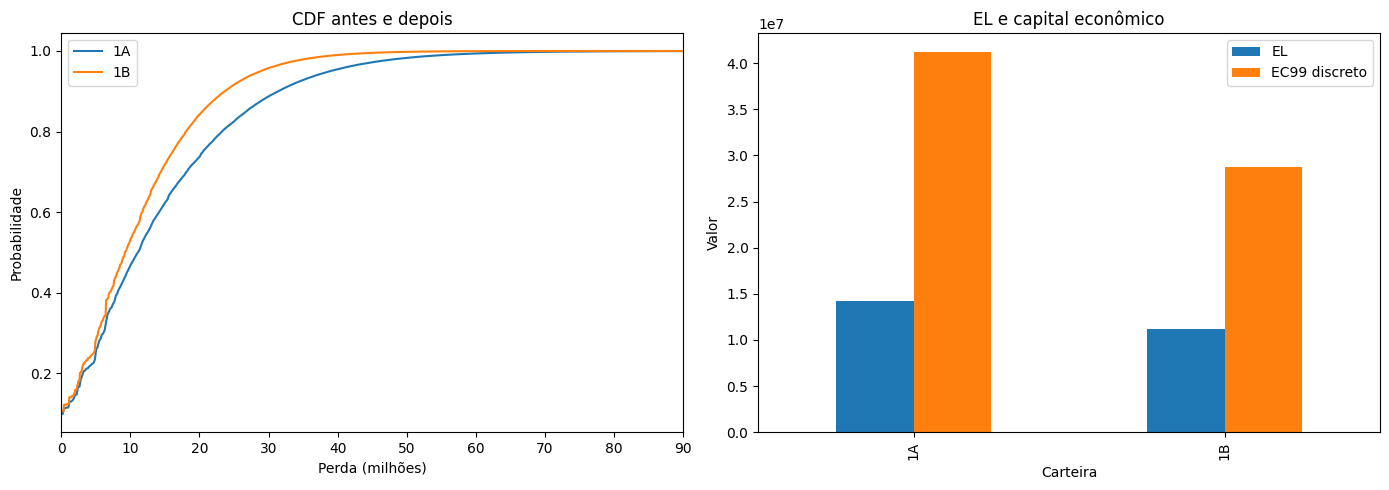

In [4]:
# Efeito da retirada sobre a distribuição e as métricas.
fig, axes = plt.subplots(1,2,figsize=(14,5))
for name, model in [('1A',model_1a),('1B',model_1b)]:
    losses=np.arange(len(model.loss_pmf))*model.unit_size
    axes[0].plot(losses/1e6,model.loss_cdf,label=name)
axes[0].set(title='CDF antes e depois',xlabel='Perda (milhões)',ylabel='Probabilidade',xlim=(0,90)); axes[0].legend()
comparison[['EL','EC99 discreto']].plot.bar(ax=axes[1])
axes[1].set(title='EL e capital econômico',ylabel='Valor',xlabel='Carteira',xticklabels=['1A','1B'])
plt.tight_layout(); plt.show()

O Exemplo 1B demonstra o efeito de concentração por recálculo completo. Para decisões de limite ou preço, a alocação A102 deve ser combinada com retorno, custos e apetite definidos fora do CreditRisk+; o modelo não prescreve automaticamente quais exposições remover.